In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os
from PIL import Image
import random
import matplotlib.pyplot as plt

In [9]:
import os

!unzip -q lfw-deepfunneled.zip

replace lfw-deepfunneled/Aaron_Eckhart/Aaron_Eckhart_0001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [12]:
# 1.1. Класс Датасета (Сиамский: берет пары лиц)
class SiameseLFWDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.people = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        self.people_with_mult = [p for p in self.people if len(os.listdir(os.path.join(root_dir, p))) >= 2]

    def __getitem__(self, index):
        same_person = random.randint(0, 1)
        if same_person:
            person = random.choice(self.people_with_mult)
            imgs = os.listdir(os.path.join(self.root_dir, person))
            p1, p2 = random.sample(imgs, 2)
            path1, path2, label = os.path.join(self.root_dir, person, p1), os.path.join(self.root_dir, person, p2), 1.0
        else:
            pers1, pers2 = random.sample(self.people, 2)
            path1 = os.path.join(self.root_dir, pers1, random.choice(os.listdir(os.path.join(self.root_dir, pers1))))
            path2 = os.path.join(self.root_dir, pers2, random.choice(os.listdir(os.path.join(self.root_dir, pers2))))
            label = 0.0
        img1, img2 = Image.open(path1).convert("RGB"), Image.open(path2).convert("RGB")
        if self.transform: img1, img2 = self.transform(img1), self.transform(img2)
        return img1, img2, torch.tensor(label)

    def __len__(self): return 1500 # Размер эпохи для скорости

# 1.2. Сама модель (Энкодер + Декодер)
class SiameseAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128) # Эмбеддинг
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 64 * 28 * 28),
            nn.Unflatten(1, (64, 28, 28)),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1), nn.Tanh()
        )

    def forward(self, x1, x2):
        e1, e2 = self.encoder(x1), self.encoder(x2)
        r1, r2 = self.decoder(e1), self.decoder(e2)
        return e1, e2, r1, r2

# Инициализация
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseAutoencoder().to(device)
transform = transforms.Compose([transforms.Resize((112, 112)), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
train_loader = DataLoader(SiameseLFWDataset('lfw-deepfunneled', transform), batch_size=32, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
def train(epochs=10):
    for epoch in range(epochs):
        model.train()
        total_loss, acc = 0, 0
        for img1, img2, label in train_loader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            optimizer.zero_grad()
            e1, e2, r1, r2 = model(img1, img2)

            # Loss 1: Реконструкция (MSE)
            loss_rec = F.mse_loss(r1, img1) + F.mse_loss(r2, img2)
            # Loss 2: Сиамский (Contrastive)
            dist = torch.pairwise_distance(e1, e2)
            loss_siamese = torch.mean(label * torch.pow(dist, 2) + (1 - label) * torch.pow(torch.clamp(1.0 - dist, min=0.0), 2))

            (loss_rec + loss_siamese).backward()
            optimizer.step()
            total_loss += (loss_rec + loss_siamese).item()
            acc += ((dist < 0.6).float() == label).float().mean().item()

        print(f"Эпоха {epoch+1} | Loss: {total_loss/len(train_loader):.3f} | Accuracy: {acc/len(train_loader):.2%}")

train(epochs=10) # Запуск обучения

Эпоха 1 | Loss: 1.547 | Accuracy: 54.06%
Эпоха 2 | Loss: 0.651 | Accuracy: 61.41%
Эпоха 3 | Loss: 0.530 | Accuracy: 66.23%
Эпоха 4 | Loss: 0.461 | Accuracy: 68.99%
Эпоха 5 | Loss: 0.434 | Accuracy: 69.48%
Эпоха 6 | Loss: 0.409 | Accuracy: 69.90%
Эпоха 7 | Loss: 0.399 | Accuracy: 69.01%
Эпоха 8 | Loss: 0.374 | Accuracy: 72.47%
Эпоха 9 | Loss: 0.364 | Accuracy: 72.14%
Эпоха 10 | Loss: 0.359 | Accuracy: 72.25%


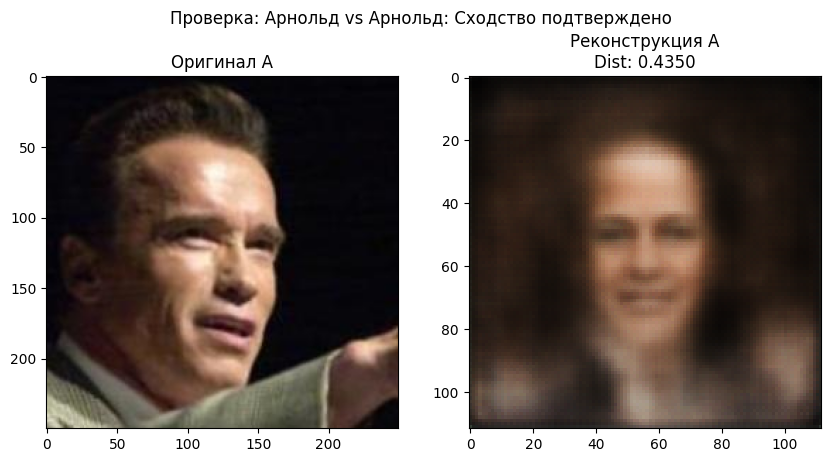

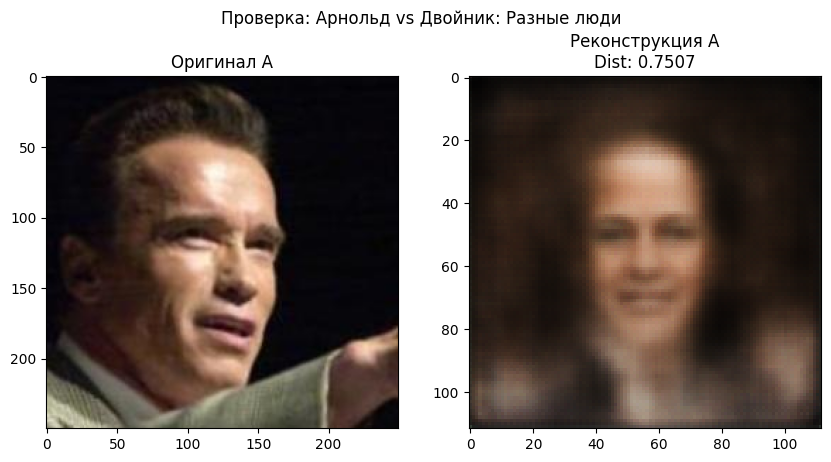

In [17]:
def verify(path_a, path_b, title="Тест верификации"):
    model.eval()
    # Загружаем фото
    img_a_raw = Image.open(path_a).convert("RGB")
    img_b_raw = Image.open(path_b).convert("RGB")

    img_a = transform(img_a_raw).unsqueeze(0).to(device)
    img_b = transform(img_b_raw).unsqueeze(0).to(device)

    with torch.no_grad():
        e1, e2, r1, r2 = model(img_a, img_b)
        dist = torch.pairwise_distance(e1, e2).item()

    # Рисуем 1 ряд: Оригиналы, 2 ряд: Что выдал Автоэнкодер
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_a_raw)
    ax[0].set_title("Оригинал A")
    ax[1].imshow(r1.squeeze().cpu().permute(1,2,0)*0.5+0.5)
    ax[1].set_title(f"Реконструкция A\nDist: {dist:.4f}")

    plt.suptitle(f"{title}: {'Сходство подтверждено' if dist < 0.6 else 'Разные люди'}")
    plt.show()

# Запуск на Арнольде
arnold_1 = 'lfw-deepfunneled/Arnold_Schwarzenegger/Arnold_Schwarzenegger_0001.jpg'
arnold_2 = 'lfw-deepfunneled/Arnold_Schwarzenegger/Arnold_Schwarzenegger_0002.jpg'
verify(arnold_1, arnold_2, title="Проверка: Арнольд vs Арнольд")

# Запуск на Двойнике
if os.path.exists('dvoinik.jpg'):
    verify(arnold_1, 'dvoinik.jpg', title="Проверка: Арнольд vs Двойник")


--- ТЕСТ 1: АРНОЛЬД VS АРНОЛЬД (из базы) ---


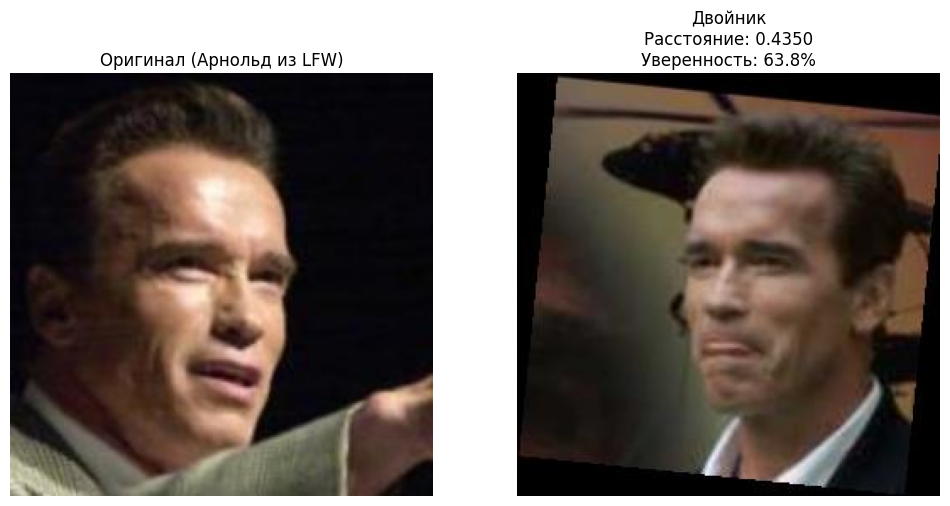

--- РЕЗУЛЬТАТ ЭКСПЕРИМЕНТА ---
Модель УВЕРЕНА (на 63.8%), что это один и тот же человек.

--- ТЕСТ 2: АРНОЛЬД VS ДВОЙНИК (загруженный) ---


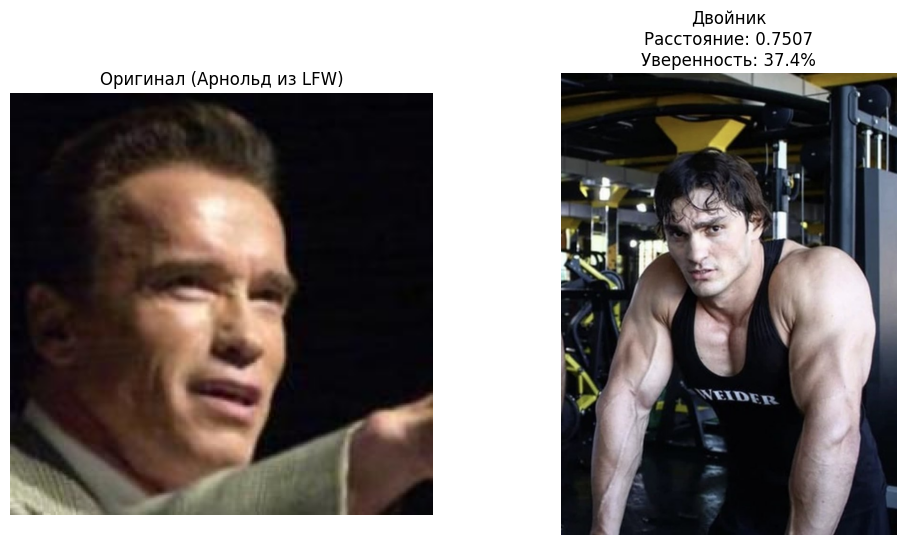

--- РЕЗУЛЬТАТ ЭКСПЕРИМЕНТА ---
Модель СЧИТАЕТ (на 62.6%), что это РАЗНЫЕ люди.


In [16]:
arnold_1 = 'lfw-deepfunneled/Arnold_Schwarzenegger/Arnold_Schwarzenegger_0001.jpg'
arnold_2 = 'lfw-deepfunneled/Arnold_Schwarzenegger/Arnold_Schwarzenegger_0002.jpg'
dvoinik = 'dvoinik.jpg'

print("--- ТЕСТ 1: АРНОЛЬД VS АРНОЛЬД (из базы) ---")
test_arnold_dvoinik(arnold_1, arnold_2)

print("\n--- ТЕСТ 2: АРНОЛЬД VS ДВОЙНИК (загруженный) ---")
if os.path.exists(dvoinik):
    test_arnold_dvoinik(arnold_1, dvoinik)
else:
    print("Файл dvoinik.jpg не найден")